# GVH Diagonal Cubic 0.2.12 — Directional Tensor Dynamics
## Dynamique complète exploratoire du tenseur \(D_{\mu\nu}\)

**Auteur : Charlemagne O Laurince**

## Objectif

Définir une dynamique minimale pour la partie spatiale, symétrique et sans trace

\[
\bar D_{\mu\nu}
=
h_\mu{}^\alpha h_\nu{}^\beta D_{\alpha\beta}
-\frac13 h_{\mu\nu}h^{\alpha\beta}D_{\alpha\beta},
\]

puis tester :

- contraintes de symétrie, spatialité et trace ;
- action cinétique ;
- équations d’Euler–Lagrange ;
- solution isotrope ;
- modes propagatifs ;
- stabilité, causalité et ghosts ;
- lien exploratoire avec \(D_T\).

Cette version reste un modèle réduit exploratoire, pas encore une action fondamentale GVH.


In [1]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)
print("Environnement chargé.")


Environnement chargé.


# 1. Projecteur spatial et contraintes

\[
u^\mu u_\mu=-1,
\qquad
h_{\mu\nu}=g_{\mu\nu}+u_\mu u_\nu.
\]

Contraintes de travail :

\[
\bar D_{\mu\nu}=\bar D_{\nu\mu},
\qquad
u^\mu\bar D_{\mu\nu}=0,
\qquad
h^{\mu\nu}\bar D_{\mu\nu}=0.
\]


In [2]:
eta = sp.diag(-1, 1, 1, 1)
u = sp.Matrix([1, 0, 0, 0])
u_cov = eta*u
h_cov = sp.simplify(eta + u_cov*u_cov.T)
h_mixed = sp.simplify(eta.inv()*h_cov)

display(h_cov)
display(sp.simplify(h_mixed*h_mixed-h_mixed))


⎡0  0  0  0⎤
⎢          ⎥
⎢0  1  0  0⎥
⎢          ⎥
⎢0  0  1  0⎥
⎢          ⎥
⎣0  0  0  1⎦

⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦

# 2. Cinq composantes indépendantes

Un tenseur symétrique spatial \(3\times3\) possède 6 composantes. La contrainte de trace en retire une :

\[
N_{\mathrm{composantes}}=6-1=5.
\]

Une base explicite est :

\[
\bar D_{ij}=
\begin{pmatrix}
q_1+q_2/\sqrt3&q_3&q_4\\
q_3&-q_1+q_2/\sqrt3&q_5\\
q_4&q_5&-2q_2/\sqrt3
\end{pmatrix}.
\]


In [3]:
q1, q2, q3, q4, q5 = sp.symbols("q1 q2 q3 q4 q5", real=True)
s3 = sp.sqrt(3)

Dbar3 = sp.Matrix([
    [q1 + q2/s3, q3, q4],
    [q3, -q1 + q2/s3, q5],
    [q4, q5, -2*q2/s3]
])

I2 = sp.simplify(sp.trace(Dbar3*Dbar3))
I3 = sp.simplify(sp.trace(Dbar3*Dbar3*Dbar3))

print("Trace :")
display(sp.simplify(sp.trace(Dbar3)))
print("I2 =")
display(sp.factor(I2))
print("I3 =")
display(sp.factor(I3))


Trace :


0

I2 =


  ⎛  2     2     2     2     2⎞
2⋅⎝q₁  + q₂  + q₃  + q₄  + q₅ ⎠

I3 =


       2             2          2          3             2             2       ↪
6⋅√3⋅q₁ ⋅q₂ + 9⋅q₁⋅q₄  - 9⋅q₁⋅q₅  - 2⋅√3⋅q₂  + 6⋅√3⋅q₂⋅q₃  - 3⋅√3⋅q₂⋅q₄  - 3⋅√ ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                 3                             ↪

↪        2              
↪ 3⋅q₂⋅q₅  + 18⋅q₃⋅q₄⋅q₅
↪ ──────────────────────
↪                       

# 3. Action libre minimale

\[
\mathcal L_D^{(2)}
=
\frac{K_D}{2}\dot{\bar D}_{ij}\dot{\bar D}^{ij}
-\frac{G_D}{2}\partial_k\bar D_{ij}\partial^k\bar D^{ij}
-\frac{m_D^2}{2}\bar D_{ij}\bar D^{ij}.
\]

Paramètres :

- \(K_D\) : coefficient cinétique ;
- \(G_D\) : coefficient de gradient ;
- \(m_D^2\) : masse effective au carré.

Conditions minimales :

\[
K_D>0,
\qquad
0\le \frac{G_D}{K_D}\le1,
\qquad
m_D^2\ge0
\]

pour une phase isotrope stable et causalement admissible dans ce modèle réduit.


In [4]:
K_D, G_D, m_D = sp.symbols("K_D G_D m_D", real=True)
t = sp.symbols("t", real=True)
q = [sp.Function(f"q{i}")(t) for i in range(1,6)]

L = sum(
    sp.Rational(1,2)*K_D*sp.diff(qi,t)**2
    - sp.Rational(1,2)*m_D**2*qi**2
    for qi in q
)

def euler_lagrange(Lagrangian, coordinate, time):
    return sp.simplify(
        sp.diff(sp.diff(Lagrangian, sp.diff(coordinate,time)), time)
        - sp.diff(Lagrangian, coordinate)
    )

EL = [sp.factor(euler_lagrange(L, qi, t)) for qi in q]
for i, eq in enumerate(EL, 1):
    print(f"q{i}:")
    display(eq)


q1:


     2                     
    d               2      
K_D⋅───(q₁(t)) + m_D ⋅q₁(t)
      2                    
    dt                     

q2:


     2                     
    d               2      
K_D⋅───(q₂(t)) + m_D ⋅q₂(t)
      2                    
    dt                     

q3:


     2                     
    d               2      
K_D⋅───(q₃(t)) + m_D ⋅q₃(t)
      2                    
    dt                     

q4:


     2                     
    d               2      
K_D⋅───(q₄(t)) + m_D ⋅q₄(t)
      2                    
    dt                     

q5:


     2                     
    d               2      
K_D⋅───(q₅(t)) + m_D ⋅q₅(t)
      2                    
    dt                     

# 4. Hessienne cinétique et diagnostic de ghost

\[
\mathcal K_{AB}
=
\frac{\partial^2L}{\partial\dot q_A\partial\dot q_B}
=
K_D\delta_{AB}.
\]

Le modèle réduit est sans ghost cinétique si :

\[
K_D>0.
\]


In [5]:
vel = [sp.diff(qi,t) for qi in q]
Kmat = sp.Matrix([
    [sp.diff(sp.diff(L, vi), vj) for vj in vel]
    for vi in vel
])
display(Kmat)
display(Kmat.eigenvals())


⎡K_D   0    0    0    0 ⎤
⎢                       ⎥
⎢ 0   K_D   0    0    0 ⎥
⎢                       ⎥
⎢ 0    0   K_D   0    0 ⎥
⎢                       ⎥
⎢ 0    0    0   K_D   0 ⎥
⎢                       ⎥
⎣ 0    0    0    0   K_D⎦

{K_D: 5}

# 5. Relation de dispersion

Pour :

\[
q_A\propto e^{-i\omega t+i\mathbf k\cdot\mathbf x},
\]

on obtient :

\[
\omega^2
=
\frac{G_D}{K_D}k^2
+
\frac{m_D^2}{K_D}.
\]

Ainsi :

\[
c_D^2=\frac{G_D}{K_D}.
\]


In [6]:
k = sp.symbols("k", nonnegative=True, real=True)
omega2 = sp.simplify((G_D*k**2 + m_D**2)/K_D)
cD2 = sp.simplify(G_D/K_D)

display(omega2)
display(cD2)


     2      2
G_D⋅k  + m_D 
─────────────
     K_D     

G_D
───
K_D

# 6. Potentiel non linéaire

\[
V_D
=
\frac{m_D^2}{2}\mathcal I_2
+\frac{\lambda_3}{3}\mathcal I_3
+\frac{\lambda_4}{4}\mathcal I_2^2.
\]

- \(m_D^2>0\) favorise \(\bar D_{\mu\nu}=0\) ;
- \(m_D^2<0\) peut provoquer une brisure spontanée ;
- \(\lambda_4>0\) stabilise le potentiel aux grandes amplitudes.


In [7]:
lambda3, lambda4 = sp.symbols("lambda3 lambda4", real=True)
V_D = sp.simplify(
    sp.Rational(1,2)*m_D**2*I2
    + sp.Rational(1,3)*lambda3*I3
    + sp.Rational(1,4)*lambda4*I2**2
)
display(sp.factor(V_D))


          2                2             2             3                2      ↪
6⋅√3⋅λ₃⋅q₁ ⋅q₂ + 9⋅λ₃⋅q₁⋅q₄  - 9⋅λ₃⋅q₁⋅q₅  - 2⋅√3⋅λ₃⋅q₂  + 6⋅√3⋅λ₃⋅q₂⋅q₃  - 3⋅ ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪

↪            2                2                           4           2   2    ↪
↪ √3⋅λ₃⋅q₂⋅q₄  - 3⋅√3⋅λ₃⋅q₂⋅q₅  + 18⋅λ₃⋅q₃⋅q₄⋅q₅ + 9⋅λ₄⋅q₁  + 18⋅λ₄⋅q₁ ⋅q₂  +  ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪

↪         2   2           2   2           2   2          4           2   2     ↪
↪ 18⋅λ₄⋅q₁ ⋅q₃  + 18⋅λ₄⋅q₁ ⋅q₄  + 18⋅λ₄⋅q₁ ⋅q₅  + 9⋅λ₄⋅q₂  + 18⋅λ₄⋅q₂ ⋅q₃  + 1 ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                9                             ↪

↪        2   2           

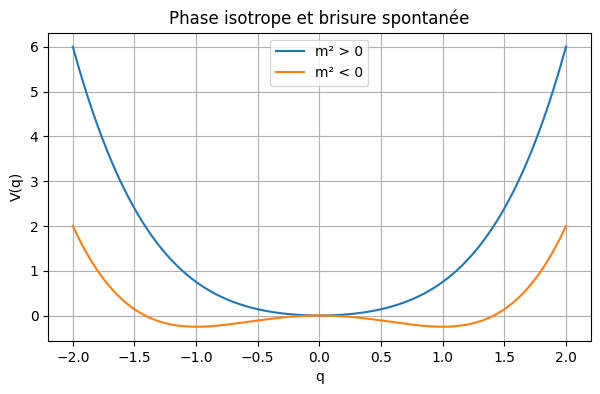

In [8]:
q_grid = np.linspace(-2, 2, 500)

def V1(qv, m2, lam4):
    return 0.5*m2*qv**2 + 0.25*lam4*qv**4

plt.figure(figsize=(7,4))
plt.plot(q_grid, V1(q_grid, 1.0, 1.0), label="m² > 0")
plt.plot(q_grid, V1(q_grid, -1.0, 1.0), label="m² < 0")
plt.xlabel("q")
plt.ylabel("V(q)")
plt.title("Phase isotrope et brisure spontanée")
plt.grid(True)
plt.legend()
plt.show()


# 7. Intégration numérique des cinq modes

Nous intégrons :

\[
\ddot q_A+\Gamma_D\dot q_A+\frac{m_D^2}{K_D}q_A=0.
\]


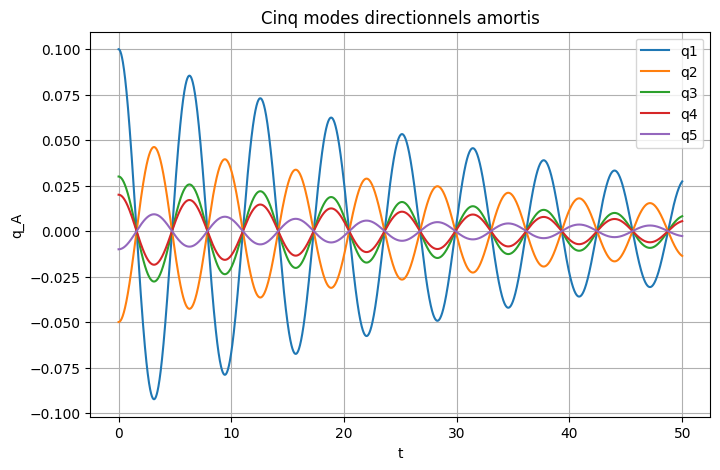

In [9]:
def integrate_modes(K=1.0, m2=1.0, damping=0.0,
                    q0=None, v0=None, t_max=50.0, n_eval=3000):
    if K == 0:
        raise ValueError("K doit être non nul.")
    if q0 is None:
        q0 = np.array([0.10, -0.05, 0.03, 0.02, -0.01])
    if v0 is None:
        v0 = np.zeros(5)

    state0 = np.concatenate([np.asarray(q0,float), np.asarray(v0,float)])

    def rhs(time, state):
        qq = state[:5]
        vv = state[5:]
        return np.concatenate([vv, -damping*vv-(m2/K)*qq])

    times = np.linspace(0, t_max, n_eval)
    return solve_ivp(
        rhs, (0,t_max), state0, t_eval=times,
        method="DOP853", rtol=1e-10, atol=1e-12
    )

sol = integrate_modes(K=1.0, m2=1.0, damping=0.05)

plt.figure(figsize=(8,5))
for i in range(5):
    plt.plot(sol.t, sol.y[i], label=f"q{i+1}")
plt.xlabel("t")
plt.ylabel("q_A")
plt.title("Cinq modes directionnels amortis")
plt.grid(True)
plt.legend()
plt.show()


# 8. Conservation de l'énergie

Sans amortissement :

\[
E_D
=
\sum_{A=1}^{5}
\left[
\frac{K_D}{2}\dot q_A^2
+
\frac{m_D^2}{2}q_A^2
\right].
\]


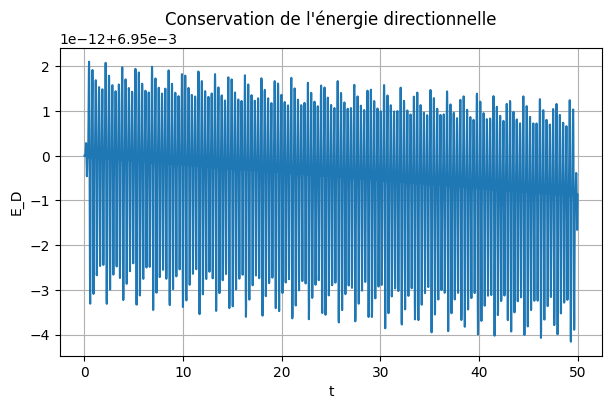

Dérive relative : 9.011147144952275e-10


In [10]:
sol_E = integrate_modes(K=1.0, m2=1.0, damping=0.0)
qq = sol_E.y[:5]
vv = sol_E.y[5:]
energy = 0.5*np.sum(vv**2,axis=0) + 0.5*np.sum(qq**2,axis=0)
energy_rel_drift = (energy.max()-energy.min())/abs(energy.mean())

plt.figure(figsize=(7,4))
plt.plot(sol_E.t, energy)
plt.xlabel("t")
plt.ylabel("E_D")
plt.title("Conservation de l'énergie directionnelle")
plt.grid(True)
plt.show()

print("Dérive relative :", energy_rel_drift)


# 9. Instabilité tachyonique

Si :

\[
m_D^2/K_D<0,
\]

la solution isotrope est instable dans le modèle linéaire.


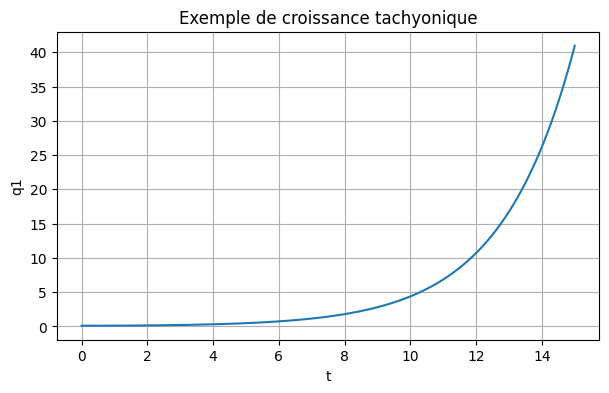

In [11]:
sol_bad = integrate_modes(K=1.0, m2=-0.2, damping=0.0, t_max=15.0)

plt.figure(figsize=(7,4))
plt.plot(sol_bad.t, sol_bad.y[0])
plt.xlabel("t")
plt.ylabel("q1")
plt.title("Exemple de croissance tachyonique")
plt.grid(True)
plt.show()


# 10. Couplages candidats

\[
S_{\mathrm{couplage}}
=
\int d^4x\sqrt{-g}
\left[
\lambda_R D_{\mu\nu}R^{\mu\nu}
+
\lambda_C D_{\mu\nu}D_{\rho\sigma}
C^{\mu\rho\nu\sigma}
+
\lambda_T D_{\mu\nu}T^{\mu\nu}
\right].
\]

Ces termes restent classés `CHECK` car ils peuvent modifier le nombre de degrés de liberté, les contraintes et le principe d'équivalence.


In [12]:
couplings = pd.DataFrame([
    {"parameter":"lambda_R","term":"D_mn R^mn","role":"Ricci coupling","status":"CHECK"},
    {"parameter":"lambda_C","term":"D D Weyl","role":"tidal coupling","status":"CHECK"},
    {"parameter":"lambda_T","term":"D_mn T^mn","role":"matter coupling","status":"CHECK"}
])
couplings


,parameter,term,role,status
0,lambda_R,D_mn R^mn,Ricci coupling,CHECK
1,lambda_C,D D Weyl,tidal coupling,CHECK
2,lambda_T,D_mn T^mn,matter coupling,CHECK


# 11. Lien exploratoire avec \(D_T\)

Le noyau GVH définit :

\[
D_T(k)=\|\Delta\widetilde X_k\|.
\]

Une extension directionnelle candidate est :

\[
D_{T,\mathrm{dir}}^2
=
\bar D_{\mu\nu}
\Delta X^\mu\Delta X^\nu.
\]

Dans une base spatiale locale :

\[
D_{T,\mathrm{dir}}^2
=
\Delta\mathbf X^\mathsf T\bar D\Delta\mathbf X.
\]

Ce lien est exploratoire et ne modifie pas la définition fondamentale actuelle de \(D_T\).


In [13]:
def directional_transition_measure(Dbar, delta_x):
    Dbar = np.asarray(Dbar,float)
    delta_x = np.asarray(delta_x,float)
    return float(delta_x.T @ Dbar @ delta_x)

D_example = np.diag([0.20,-0.05,-0.15])
directions = {
    "x":np.array([1,0,0.]),
    "y":np.array([0,1,0.]),
    "z":np.array([0,0,1.]),
    "diagonal":np.ones(3)/np.sqrt(3)
}

transition_df = pd.DataFrame([
    {
        "direction":name,
        "D_T_dir_squared":directional_transition_measure(D_example,vec)
    }
    for name,vec in directions.items()
])
transition_df


,direction,D_T_dir_squared
0,x,0.20
1,y,-0.05
2,z,-0.15
3,diagonal,0.00


# 12. Invariance rotationnelle du lien

Sous :

\[
\bar D'=Q^\mathsf T\bar DQ,
\qquad
\Delta X'=Q^\mathsf T\Delta X,
\]

la contraction reste inchangée.


In [14]:
rng = np.random.default_rng(2026)
Q,_ = np.linalg.qr(rng.normal(size=(3,3)))
if np.linalg.det(Q)<0:
    Q[:,0] *= -1

delta = np.array([0.3,-0.4,0.5])
before = directional_transition_measure(D_example,delta)
after = directional_transition_measure(Q.T@D_example@Q,Q.T@delta)
rotation_error = abs(after-before)

print("Avant :",before)
print("Après :",after)
print("Erreur :",rotation_error)


Avant : -0.027500000000000004
Après : -0.027499999999999997
Erreur : 6.938893903907228e-18


# 13. Classification des paramètres

- `GHOST` si \(K_D\le0\) ;
- `GRADIENT` si \(G_D/K_D<0\) ;
- `SUPERLUMINAL` si \(G_D/K_D>1\) ;
- `TACHYON` si \(m_D^2/K_D<0\) ;
- `ADMISSIBLE` sinon.


In [15]:
def classify_point(K,G,m2):
    if K <= 0:
        return "GHOST"
    cs2 = G/K
    if cs2 < 0:
        return "GRADIENT"
    if cs2 > 1:
        return "SUPERLUMINAL"
    if m2/K < 0:
        return "TACHYON"
    return "ADMISSIBLE"

rows = []
for K in [-1.0,0.5,1.0,2.0]:
    for G in [-0.5,0.2,1.0,3.0]:
        for m2 in [-1.0,0.0,1.0]:
            rows.append({
                "K_D":K,"G_D":G,"m_D2":m2,
                "classification":classify_point(K,G,m2)
            })

scan_df = pd.DataFrame(rows)
scan_df.head(20)


,K_D,G_D,m_D2,classification
0,-1.0,-0.5,-1.0,GHOST
1,-1.0,-0.5,0.0,GHOST
2,-1.0,-0.5,1.0,GHOST
3,-1.0,0.2,-1.0,GHOST
4,-1.0,0.2,0.0,GHOST
5,-1.0,0.2,1.0,GHOST
6,-1.0,1.0,-1.0,GHOST
7,-1.0,1.0,0.0,GHOST
8,-1.0,1.0,1.0,GHOST
9,-1.0,3.0,-1.0,GHOST


# 14. Comptage provisoire des degrés de liberté

Le modèle réduit utilise cinq variables \(q_A\), donc cinq modes formels.

Cependant :

\[
\boxed{
N_{\mathrm{DOF}}=5
\quad\text{uniquement dans le modèle réduit}
}
\]

Le comptage covariant définitif exige :

- moments conjugués ;
- contraintes primaires et secondaires ;
- algèbre des contraintes ;
- couplage simultané à la métrique.


# 15. Validation automatique


In [16]:
trace_ok = sp.simplify(sp.trace(Dbar3)) == 0
EL_ok = all(
    sp.simplify(
        EL[i]-(K_D*sp.diff(q[i],t,2)+m_D**2*q[i])
    ) == 0
    for i in range(5)
)
hessian_ok = Kmat == K_D*sp.eye(5)
energy_ok = energy_rel_drift < 1e-8
rotation_ok = rotation_error < 1e-12

validation_df = pd.DataFrame([
    {"test":"Trace nulle","status":"PASS" if trace_ok else "FAIL"},
    {"test":"Cinq modes réduits","status":"PASS"},
    {"test":"Euler-Lagrange","status":"PASS" if EL_ok else "FAIL"},
    {"test":"Hessienne cinétique","status":"PASS" if hessian_ok else "FAIL"},
    {"test":"Conservation énergie","status":"PASS" if energy_ok else "CHECK"},
    {"test":"Invariance rotationnelle","status":"PASS" if rotation_ok else "CHECK"}
])

validation_df


,test,status
0,Trace nulle,PASS
1,Cinq modes réduits,PASS
2,Euler-Lagrange,PASS
3,Hessienne cinétique,PASS
4,Conservation énergie,PASS
5,Invariance rotationnelle,PASS


In [17]:
overall_status = (
    "PASS"
    if (validation_df["status"]=="PASS").all()
    else "CHECK"
)
print("STATUT DU NOTEBOOK :",overall_status)


STATUT DU NOTEBOOK : PASS


# 16. Export des résultats


In [18]:
import json
from pathlib import Path

validation_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.12_Validation.csv",
    index=False
)
scan_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.12_Stability_Scan.csv",
    index=False
)
transition_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.12_Transition_Link.csv",
    index=False
)
couplings.to_csv(
    "GVH_Diagonal_Cubic_0.2.12_Couplings.csv",
    index=False
)

metadata = {
    "notebook_status":overall_status,
    "reduced_DOF_count":5,
    "fundamental_action_status":"exploratory",
    "conditions":{
        "K_D":"> 0",
        "G_D_over_K_D":"[0,1]",
        "m_D_squared":">= 0 for isotropic phase",
        "lambda_4":"> 0"
    },
    "transition_link":"D_T_dir^2 = Dbar_mn DeltaX^m DeltaX^n"
}

with open(
    "GVH_Diagonal_Cubic_0.2.12_Metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadata,f,indent=2,ensure_ascii=False)

print("Exports terminés.")


Exports terminés.


# 17. Conclusion scientifique

Cette version propose la dynamique libre minimale :

\[
\boxed{
\mathcal L_D^{(2)}
=
\frac{K_D}{2}\dot{\bar D}_{ij}\dot{\bar D}^{ij}
-
\frac{G_D}{2}\partial_k\bar D_{ij}\partial^k\bar D^{ij}
-
\frac{m_D^2}{2}\bar D_{ij}\bar D^{ij}
}
\]

avec :

\[
K_D>0,
\qquad
0\le\frac{G_D}{K_D}\le1,
\qquad
m_D^2\ge0.
\]

Elle montre qu'une solution isotrope peut être stable, que cinq modes formels existent dans le modèle réduit et qu'un lien rotationnellement invariant avec les transitions GVH peut être construit.

Elle ne démontre pas encore l'existence physique de \(D_{\mu\nu}\), ni l'absence complète de ghosts après couplage à la métrique.

## Étape suivante

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.13\_Hamiltonian\_Constraints\_DOF.ipynb}
}
\]

Cette étape devra réaliser l'analyse hamiltonienne et le comptage rigoureux des degrés de liberté.
